<a href="https://colab.research.google.com/github/BuddhikaRoshan/HemoAi/blob/Heshani/oooo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import matplotlib.pyplot as plt


import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
# ==========================================
# SETTINGS
# ==========================================
IMG_SIZE = 64
BATCH_SIZE = 8
EPOCHS = 30
SELECTED_SHAPES = 5

TARGET_SHAPE_COUNT = 1000
TARGET_THAL_COUNT = 1000

shape_dir = "/content/drive/MyDrive/thalassemia_shape_based/dataset2/shapes"
disease_dir = "/content/drive/MyDrive/thalassemia_shape_based/dataset/disease"

In [ ]:
def preprocess_image(path):
    img = cv2.imread(path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Contrast enhancement
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

In [ ]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

def augment_image_array(img):
    img = tf.expand_dims(img, 0)
    img = augment(img)
    return img[0].numpy()

In [ ]:
def load_shape_data_balanced(folder):
    images, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        path = os.path.join(folder, cls)
        if not os.path.isdir(path):
            continue

        files = [f for f in os.listdir(path)
                 if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif'))]

        class_imgs = []

        for file in files:
            img = preprocess_image(os.path.join(path, file))
            if img is not None:
                class_imgs.append(img)

        if len(class_imgs) == 0:
            continue

        # original images
        for img in class_imgs:
            images.append(img)
            labels.append(idx)

        # augmentation to balance
        current = len(class_imgs)
        i = 0
        while current < TARGET_SHAPE_COUNT:
            img = class_imgs[i % len(class_imgs)]
            images.append(augment_image_array(img))
            labels.append(idx)
            current += 1
            i += 1

        print(f"{cls}: {current}")

    return np.array(images), np.array(labels), classes

In [ ]:

from tensorflow.keras import layers, models
import tensorflow as tf

def build_mobilenet_vit_model(num_classes):

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = augment(inputs)

    # -------------------------
    # CNN Backbone (MobileNet)
    # -------------------------
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )

    # Freeze most layers
    for layer in base.layers[:-30]:
        layer.trainable = False

    x = base.output   # shape: (None, H, W, C)

    # -------------------------
    # Convert CNN feature map → patches (for ViT)
    # -------------------------
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    num_patches = h * w

    x = layers.Reshape((num_patches, c))(x)

    # Linear projection
    projection_dim = 64
    x = layers.Dense(projection_dim)(x)

    # -------------------------
    # Transformer Block (ViT)
    # -------------------------
    num_heads = 4
    transformer_units = 128

    # LayerNorm
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)

    # Multi-head attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim
    )(x1, x1)

    # Skip connection
    x2 = layers.Add()([attention_output, x])

    # Feed-forward network
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = layers.Dense(transformer_units, activation="relu")(x3)
    x3 = layers.Dense(projection_dim)(x3)

    x = layers.Add()([x3, x2])

    # -------------------------
    # Classification Head
    # -------------------------
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_shape_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
# Ensure shape_classes is defined by loading the data first.
# We only need the classes for building the model in this step.
# X_shapes and y_shapes will be reloaded and properly split in a subsequent cell (s2kObOsT7oN5) for training.
X_dummy, y_dummy, shape_classes = load_shape_data_balanced(shape_dir)
shape_model = build_mobilenet_vit_model(len(shape_classes))

acantocyte: 1000
elliptocyte: 1000
hypochromic: 1000
normal: 1000
pencil: 1000
sperobulat: 1000
stomatocyte: 1000
target: 1000
teardrop: 1000


/tmp/ipykernel_2580/3592425324.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Assuming IMG_SIZE is now 96, and shape_dir is defined.
# Need to reload data because IMG_SIZE was changed from 128 to 96.
print("Reloading shape dataset with updated IMG_SIZE...")
X_shapes, y_shapes, shape_classes = load_shape_data_balanced(shape_dir)

# Convert labels to categorical
y_shapes_cat = tf.keras.utils.to_categorical(y_shapes, len(shape_classes))

# Redefine the augment layer with the updated IMG_SIZE
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Rebuild the shape model to ensure its input layer matches the new IMG_SIZE
# and number of classes. `build_mobilenet_vit_model` uses the global IMG_SIZE.
shape_model = build_mobilenet_vit_model(len(shape_classes))

# Split data again with the new X_shapes and y_shapes_cat
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_shapes,
    y_shapes_cat,
    test_size=0.2,
    stratify=y_shapes,   # VERY IMPORTANT
    random_state=42
)

history = shape_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Reloading shape dataset with updated IMG_SIZE...
acantocyte: 1000
elliptocyte: 1000
hypochromic: 1000
normal: 1000
pencil: 1000
sperobulat: 1000
stomatocyte: 1000
target: 1000
teardrop: 1000


/tmp/ipykernel_2580/3592425324.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Epoch 1/30
900/900 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4329 - loss: 1.6382
Epoch 1: val_accuracy improved from None to 0.69944, saving model to best_shape_model.keras

Epoch 1: finished saving model to best_shape_model.keras
900/900 ━━━━━━━━━━━━━━━━━━━━ 51s 37ms/step - accuracy: 0.5833 - loss: 1.2418 - val_accuracy: 0.6994 - val_loss: 0.8768 - learning_rate: 1.0000e-04
Epoch 2/30
899/900 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7399 - loss: 0.8280
Epoch 2: val_accuracy improved from 0.69944 to 0.83222, saving model to best_shape_model.keras

Epoch 2: finished saving model to best_shape_model.keras
900/900 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.7579 - loss: 0.7668 - val_accuracy: 0.8322 - val_loss: 0.4750 - learning_rate: 1.0000e-04
Epoch 3/30
899/900 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8115 - loss: 0.6269
Epoch 3: val_accuracy improved from 0.83222 to 0.84278, saving model to best_shape_model.keras

Epoch 3: finished saving model to best_shape_m

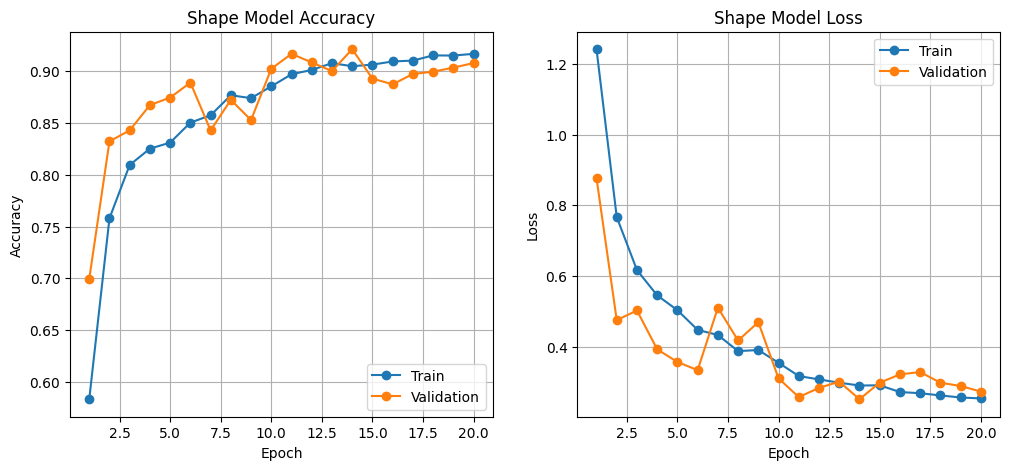

In [ ]:


epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, history.history['accuracy'], marker='o')
plt.plot(epochs_range, history.history['val_accuracy'], marker='o')
plt.title("Shape Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, history.history['loss'], marker='o')
plt.plot(epochs_range, history.history['val_loss'], marker='o')
plt.title("Shape Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np

# Predict on validation/test set
y_pred = np.argmax(shape_model.predict(X_val), axis=1)
y_true = np.argmax(y_val, axis=1)

# ===== Print Test Accuracy (like your screenshot) =====
test_acc = accuracy_score(y_true, y_pred)
print("TEST ACCURACY:", test_acc)

# ===== Classification report as table =====
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=shape_classes,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step
TEST ACCURACY: 0.9211111111111111


,precision,recall,f1-score,support
acantocyte,1.000000,0.965000,0.982188,200.000000
elliptocyte,0.730038,0.960000,0.829374,200.000000
hypochromic,0.967105,0.735000,0.835227,200.000000
normal,0.845455,0.930000,0.885714,200.000000
pencil,1.000000,0.945000,0.971722,200.000000
sperobulat,0.969849,0.965000,0.967419,200.000000
stomatocyte,0.964912,0.825000,0.889488,200.000000
target,0.914692,0.965000,0.939173,200.000000
teardrop,0.990099,1.000000,0.995025,200.000000
accuracy,0.921111,0.921111,0.921111,0.921111


In [ ]:
shape_model.save("shape_modeln2.1.keras")
print("Shape model saved")

Shape model saved


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# -----------------------------
# SETTINGS
# -----------------------------
IMG_SIZE = 96
BATCH_SIZE = 16
EPOCHS = 30

dataset_path = "/content/drive/MyDrive/thalassemia_shape_based/dataset/disease"


In [ ]:
shape_model = tf.keras.models.load_model("/content/best_shape_model.keras")

In [ ]:
shape_model.save("/content/drive/MyDrive/thalassemia_shape_based/shape_model_o.keras")
print("✅ Shape model saved!")

✅ Shape model saved!


Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 29s 169ms/step - accuracy: 0.7000 - loss: 0.6619 - val_accuracy: 0.9242 - val_loss: 0.3275
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8565 - loss: 0.3833 - val_accuracy: 0.9667 - val_loss: 0.2110
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9039 - loss: 0.3136 - val_accuracy: 0.9848 - val_loss: 0.1733
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9331 - loss: 0.2654 - val_accuracy: 0.9879 - val_loss: 0.1618
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9364 - loss: 0.2577 - val_accuracy: 0.9909 - val_loss: 0.1546
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9403 - loss: 0.2604 - val_accuracy: 0.9909 - val_loss: 0.1513
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9539 - loss: 0.2382 - val_accuracy: 0.9939 - val_loss: 0.1489
Epoch 8/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9500 - loss: 0.2425 - val_accuracy: 0.9909 -

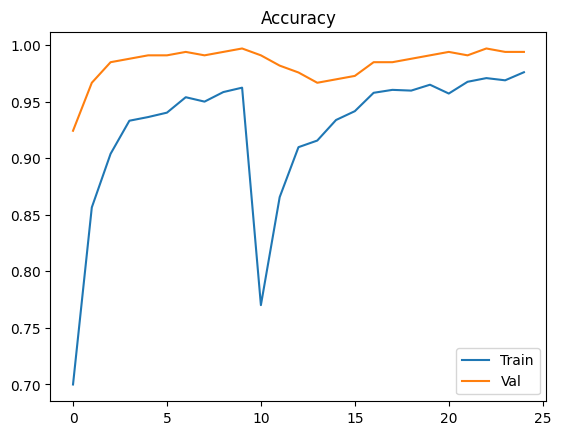

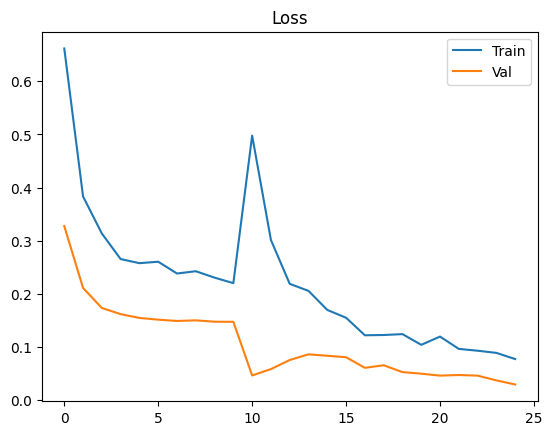

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 548ms/step
Best Threshold: 0.6100000000000003
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

FINAL RESULTS
Accuracy : 0.996969696969697
Precision: 1.0
Recall   : 0.9939393939393939
F1 Score : 0.9969604863221885


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =============================
# SETTINGS
# =============================
IMG_SIZE = 128
TARGET_COUNT = 1100
BASE_PATH = "/content/drive/MyDrive/thalassemia_shape_based"

# =============================
# LOAD SHAPE MODEL
# =============================
shape_model_path = None
for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file.endswith(".keras") or file.endswith(".h5"):
            shape_model_path = os.path.join(root, file)
            break
    if shape_model_path:
        break

shape_model = tf.keras.models.load_model(shape_model_path, compile=False)

# =============================
# AUGMENTATION
# =============================
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.12)
])

def augment_image(img):
    img = tf.expand_dims(img, 0)
    return augment(img)[0].numpy()

# =============================
# PREPROCESS
# =============================
def preprocess_image(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0

# =============================
# SHAPE FEATURES
# =============================
def get_shape_features(img):
    img_small = cv2.resize(img, (64, 64))
    img_small = np.expand_dims(img_small, 0)
    pred = shape_model.predict(img_small, verbose=0)[0]
    return pred / (np.sum(pred) + 1e-6)

# =============================
# LOAD DATA
# =============================
dataset_path = BASE_PATH + "/dataset/disease"
class_data = {0: [], 1: []}

for cls in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, cls)
    if not os.path.isdir(folder):
        continue

    label = 0 if cls.lower() == "healthy" else 1

    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".jpg",".png",".jpeg")):
                img = preprocess_image(os.path.join(root, f))
                if img is not None:
                    class_data[label].append(img)

# =============================
# BALANCE DATA
# =============================
images, features, labels = [], [], []

for label, imgs in class_data.items():
    i = 0
    while len(imgs) < TARGET_COUNT:
        imgs.append(augment_image(imgs[i % len(imgs)]))
        i += 1

    for img in imgs:
        images.append(img)
        features.append(get_shape_features(img))
        labels.append(label)

images = np.array(images)
features = np.array(features)
labels = np.array(labels)

# =============================
# SPLIT
# =============================
X_train_img, X_temp_img, X_train_feat, X_temp_feat, y_train, y_temp = train_test_split(
    images, features, labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

X_val_img, X_test_img, X_val_feat, X_test_feat, y_val, y_test = train_test_split(
    X_temp_img, X_temp_feat, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# =============================
# MODEL
# =============================
img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

for layer in base.layers:
    layer.trainable = False

x = base(img_input)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

feat_input = layers.Input(shape=(features.shape[1],))
f = layers.BatchNormalization()(feat_input)
f = layers.Dense(64, activation="relu")(f)

combined = layers.concatenate([x, f])

z = layers.Dense(64, activation="relu")(combined)
z = layers.BatchNormalization()(z)
z = layers.Dropout(0.5)(z)

output = layers.Dense(1, activation="sigmoid")(z)

model = models.Model([img_input, feat_input], output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

# =============================
# TRAIN STAGE 1
# =============================
hist1 = model.fit(
    [X_train_img, X_train_feat],
    y_train,
    validation_data=([X_val_img, X_val_feat], y_val),
    epochs=10,
    batch_size=16,
    verbose=1
)

# =============================
# FINE-TUNE
# =============================
for layer in base.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

hist2 = model.fit(
    [X_train_img, X_train_feat],
    y_train,
    validation_data=([X_val_img, X_val_feat], y_val),
    epochs=15,
    batch_size=16,
    verbose=1
)

# =============================
# 🔥 COMBINE HISTORY
# =============================
history = {}
for key in hist1.history:
    history[key] = hist1.history[key] + hist2.history[key]

# =============================
# 🔍 OVERFITTING CHECK
# =============================
print("\nOVERFITTING CHECK")

train_acc = history['accuracy'][-1]
val_acc = history['val_accuracy'][-1]

train_loss = history['loss'][-1]
val_loss = history['val_loss'][-1]

print(f"Train Acc: {train_acc:.4f}")
print(f"Val Acc  : {val_acc:.4f}")
print(f"Train Loss: {train_loss:.4f}")
print(f"Val Loss  : {val_loss:.4f}")

if train_acc - val_acc > 0.05:
    print("⚠️ OVERFITTING detected")
else:
    print("✅ No strong overfitting")

# =============================
# 📊 GRAPHS
# =============================
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()

# =============================
# THRESHOLD TUNING
# =============================
y_prob = model.predict([X_val_img, X_val_feat])

best_acc = 0
best_thresh = 0.5

for t in np.arange(0.3, 0.7, 0.01):
    y_pred = (y_prob > t).astype(int)
    acc = accuracy_score(y_val, y_pred)
    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("Best Threshold:", best_thresh)

# =============================
# FINAL TEST
# =============================
y_prob = model.predict([X_test_img, X_test_feat])
y_pred = (y_prob > best_thresh).astype(int)

print("\nFINAL RESULTS")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

In [ ]:
# =============================
# 💾 SAVE MODEL
# =============================

SAVE_PATH = BASE_PATH + "/content/drive/MyDrive"
os.makedirs(SAVE_PATH, exist_ok=True)

# Save in new Keras format (.keras)
model.save(os.path.join(SAVE_PATH, "thalassemia_model_o.keras"))

# Save in HDF5 format (.h5)
model.save(os.path.join(SAVE_PATH, "thalassemia_model_o.h5"))

print("✅ Model saved successfully!")

✅ Model saved successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction: Thalassemia
Probability: 0.943235456943512
CNN Model: mobilenetv2_1.00_128
Last Conv Layer: Conv_1


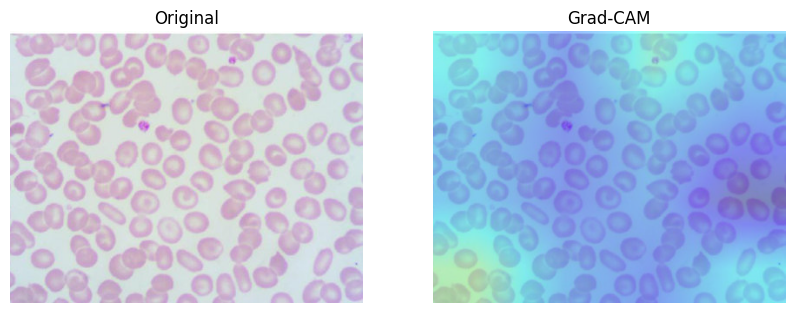

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =============================
# LOAD MODELS (FIX PATHS)
# =============================
BASE_PATH = "/content/drive/MyDrive/thalassemia_shape_based"

thal_model = tf.keras.models.load_model(f"{BASE_PATH}/saved_models/thalassemia_model_o.keras")
shape_model = tf.keras.models.load_model(f"{BASE_PATH}/shape_model_o.keras", compile=False)

IMG_SIZE = 128

# =============================
# PREPROCESS
# =============================
def preprocess_image(path):
    img = cv2.imread(path)
    if img is None:
        print("❌ Image not found")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0

# =============================
# SHAPE FEATURES
# =============================
def get_shape_features(img):
    img_small = cv2.resize(img, (64, 64))
    img_small = np.expand_dims(img_small, 0)

    pred = shape_model.predict(img_small, verbose=0)[0]
    return pred / (np.sum(pred) + 1e-6)

# =============================
# LOAD IMAGE
# =============================
image_path = f"{BASE_PATH}/tha1_test.png"

original_img = cv2.imread(image_path)

if original_img is None:
    raise ValueError("❌ Image not found!")

original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

img = preprocess_image(image_path)

img_input = np.expand_dims(img, 0)
feat_input = np.expand_dims(get_shape_features(img), 0)

# =============================
# PREDICTION
# =============================
pred = thal_model.predict([img_input, feat_input])[0][0]

print("Prediction:", "Thalassemia" if pred > 0.5 else "Healthy")
print("Probability:", float(pred))

# =============================
# 🔥 EXTRACT CNN (MobileNet)
# =============================
def get_cnn_model(full_model):
    for layer in full_model.layers:
        if isinstance(layer, tf.keras.Model):  # nested model
            return layer
    raise ValueError("❌ CNN model not found")

cnn_model = get_cnn_model(thal_model)

print("CNN Model:", cnn_model.name)

# =============================
# FIND LAST CONV
# =============================
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("❌ No Conv layer found")

last_conv_layer_name = find_last_conv_layer(cnn_model)
print("Last Conv Layer:", last_conv_layer_name)

# =============================
# 🔥 GRAD-CAM (FIXED)
# =============================
def make_gradcam_heatmap(img_array, cnn_model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=cnn_model.input,
        outputs=[
            cnn_model.get_layer(last_conv_layer_name).output,
            cnn_model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap

# =============================
# HEATMAP OVERLAY
# =============================
def overlay_heatmap(original_img, heatmap):

    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    return cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)

# =============================
# APPLY GRAD-CAM
# =============================
if pred > 0.5:
    heatmap = make_gradcam_heatmap(
        img_input,
        cnn_model,
        last_conv_layer_name
    )

    result = overlay_heatmap(original_img, heatmap)
else:
    result = original_img.copy()

# =============================
# DISPLAY
# =============================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Grad-CAM")
plt.axis('off')

plt.show()